In [13]:
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, TextVectorization
from tensorflow.keras.optimizers import Adam

nltk.download('stopwords')

data = np.load('es-sentimientos.npy', allow_pickle=True)
frases = data[0]
etiquetas = np.array([int(e) for e in data[1]])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Limpieza del dataset, quitando stop-words, signos de puntuación y pasando las palabras a minúscula
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(f"[{re.escape(string.punctuation)}]", "", texto)
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return " ".join(palabras)

frases_limpias = [limpiar_texto(f) for f in frases]

frases_limpias[:10]

['siento increíblemente feliz hoy',
 'saliendo perfectamente bien',
 'hoy gran día ser feliz',
 'cada día siento agradecido vida',
 'necesito ser feliz',
 'esfuerzo dando frutos',
 'siempre encuentro positivo cada situación',
 'cada paso doy acerca sueños',
 'rodeo personas inspiran',
 'aprendiendo creciendo cada día']

In [44]:
# Capa de TextVectorization para limpiar y tokenizar
vectorizer = TextVectorization(output_mode='int', output_sequence_length=100)
vectorizer.adapt(frases_limpias)

# Transformación de las frases usando el vectorizador
X = vectorizer(frases_limpias)
y = etiquetas

# Creación del modelo
model = Sequential([
    Embedding(input_dim=vectorizer.vocabulary_size(), output_dim=50, input_length=100),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['acc'])

# Entrenamiento
h = model.fit(X, y, epochs=100, batch_size=4, validation_split=0.2)

# Ejemplo de predicción
frase_prueba = "Hoy me encuentro mal"
frase_prueba_limpia = limpiar_texto(frase_prueba)

# Transformación de la frase de prueba
secuencia_padded = vectorizer([frase_prueba_limpia])

# Predicción
pred = model.predict(secuencia_padded)
print(f"Predicción: {'Positiva' if pred[0][0] > 0.5 else 'Negativa'}")

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - acc: 0.6327 - loss: 0.6851 - val_acc: 0.0000e+00 - val_loss: 1.0324
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.5923 - loss: 0.6863 - val_acc: 0.0000e+00 - val_loss: 1.0507
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6724 - loss: 0.6345 - val_acc: 0.0000e+00 - val_loss: 0.8816
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.5905 - loss: 0.6774 - val_acc: 0.0000e+00 - val_loss: 0.9864
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.5818 - loss: 0.6843 - val_acc: 0.0000e+00 - val_l

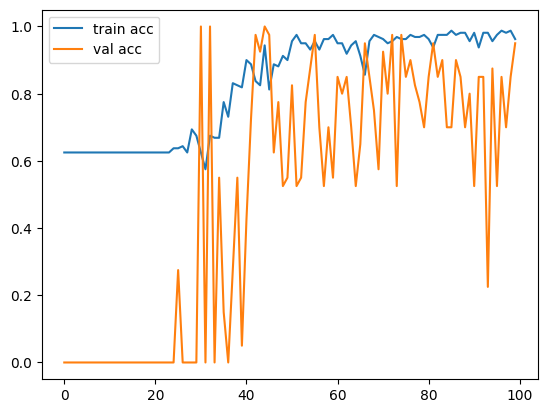

In [45]:
import matplotlib.pyplot as plt
plt.plot(h.history['acc'], label='train acc')
plt.plot(h.history['val_acc'], label='val acc')
plt.legend()